In [85]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal,Annotated
from langchain_openrouter import ChatOpenRouter
from langchain_core.messages import SystemMessage,HumanMessage
import operator

In [86]:
genrator_llm = ChatOpenRouter(model='nvidia/nemotron-3-ultra-550b-a55b:free')
evaluation_llm = ChatOpenRouter(model='nvidia/nemotron-3-ultra-550b-a55b:free')
optimization_llm = ChatOpenRouter(model='nvidia/nemotron-3-ultra-550b-a55b:free')

In [87]:

from pydantic import BaseModel, Field

class TweetEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")

In [88]:

structured_evaluator_llm = evaluation_llm.with_structured_output(TweetEvaluation)

In [89]:
# State
class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved","needs_improvement"]
    feedback: str
    iteration: int
    max_iteration: int
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str],operator.add]


In [90]:
def genrate_tweet(state: TweetState):

    #prompt
    messages = [
        SystemMessage(content="you are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
Write a short, original, and hiliarious tweet on the topic: "{state['topic']}".
        
Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observation humor, irony,sarcasm, or cultural reference.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english.
""")
    ]
    #send_genrator_llm
    response = genrator_llm.invoke(messages).content

    #return_response
    return {'tweet': response, 'tweet_history': [response]}

In [91]:
def evaluate_tweet(state: TweetState):

   
    mess = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
Evaluate the following tweet:

Tweet: "{state['tweet']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
""")
]

    response = structured_evaluator_llm.invoke(mess)
    return {'evaluation': response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}
    

In [92]:
def optimizer_tweet(state: TweetState):

    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
""")
    ]

    response = optimization_llm.invoke(messages).content
    iteration = state['iteration'] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}

In [93]:
def route_evaluation(state: TweetState):

    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iteration']:
        return 'approved'
    else:
        return 'needs_improvement'

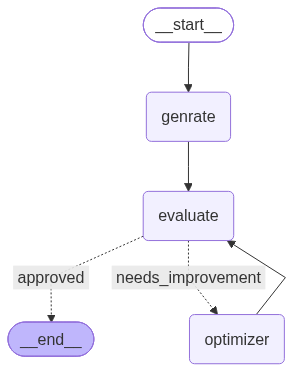

In [94]:
graph = StateGraph(TweetState)

graph.add_node('genrate',genrate_tweet)
graph.add_node('evaluate',evaluate_tweet)
graph.add_node('optimizer',optimizer_tweet)

graph.add_edge(START,'genrate')
graph.add_edge('genrate','evaluate')

graph.add_conditional_edges('evaluate',route_evaluation,{'approved': END, 'needs_improvement': 'optimizer'})
graph.add_edge('optimizer','evaluate')

workflow = graph.compile()
workflow

In [97]:
intial_state = {
    "topic": "school life",
    "iteration": 1,
    "max_iteration": 5
}
workflow.invoke(intial_state)

{'topic': 'school life',
 'tweet': 'The hardest math problem in school wasn\'t calculus. It was calculating the exact second the bell rings so you can pack up *before* the teacher says "the bell doesn\'t dismiss you, I do."',
 'evaluation': 'approved',
 'feedback': 'This tweet hits hard with universalспособов.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadrant.quadr